# Phase 10: YOLOv8 Leaf Detector Model Evaluation

This notebook locates the latest custom-trained leaf detector model weights (handling auto-increment directories like `yolov8n_leaf_detection-2`), runs inference tests on validation images, and plots the bounding box visual overlays.

In [7]:
# Setup paths and imports
from pathlib import Path
import sys
import glob
import re
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'ai' and PROJECT_ROOT.parent != PROJECT_ROOT:
    if (PROJECT_ROOT / 'ai').exists():
        PROJECT_ROOT = PROJECT_ROOT / 'ai'
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import utils

In [8]:
# Locate latest training weights run folder inside outputs/runs/detect/
run_dirs = glob.glob(str(PROJECT_ROOT / "outputs/runs/detect/yolov8n_leaf_detection*")) + \
           glob.glob(str(PROJECT_ROOT.parent / "outputs/runs/detect/yolov8n_leaf_detection*"))

def get_run_index(path_str):
    match = re.search(r'yolov8n_leaf_detection-(\d+)', path_str)
    return int(match.group(1)) if match else 1

if run_dirs:
    run_dirs.sort(key=get_run_index, reverse=True)
    latest_run = Path(run_dirs[0])
    best_weights = latest_run / "weights" / "best.pt"
    print("✅ Located latest custom training weights folder:", latest_run)
else:
    best_weights = Path("outputs/runs/detect/yolov8n_leaf_detection/weights/best.pt")
    print("⚠️ No training folders detected. Falling back to default path:", best_weights)

✅ Located latest custom training weights folder: o:\Hackthons\KrishiOS\ai\outputs\runs\detect\yolov8n_leaf_detection-8


Inference target: O:\Hackthons\KrishiOS\ai\datasets\detection\plantdoc\test\images\%2320+Bacterial+Spot+and+Speck_jpg.rf.56abfa1b8c07239d7a7b67f36649a105.jpg

image 1/1 O:\Hackthons\KrishiOS\ai\datasets\detection\plantdoc\test\images\%2320+Bacterial+Spot+and+Speck_jpg.rf.56abfa1b8c07239d7a7b67f36649a105.jpg: 416x416 1 leaf, 17.0ms
Speed: 2.1ms preprocess, 17.0ms inference, 3.3ms postprocess per image at shape (1, 3, 416, 416)


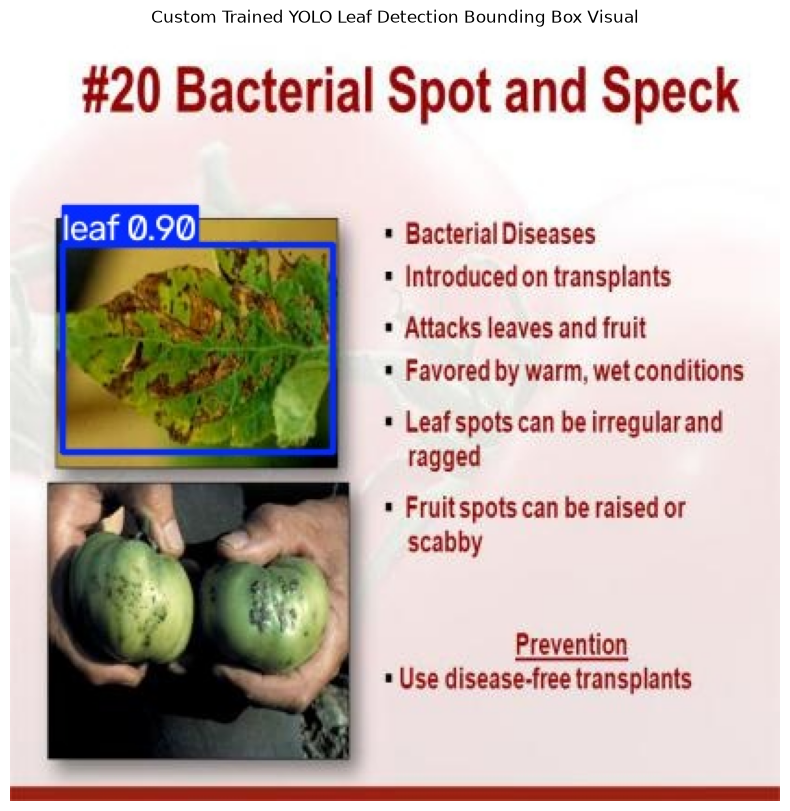

In [10]:
# Run visual prediction overlay validation
dataset_dir = utils.paths.DETECTION_DATASET_DIR
test_images = list((dataset_dir / "test" / "images").glob("*.jpg")) + \
               list((dataset_dir / "test" / "images").glob("*.JPG"))

if best_weights.exists() and test_images:
    model_trained = YOLO(best_weights)
    test_img_path = test_images[0]
    print("Inference target:", test_img_path)
    
    # Run prediction
    pred_results = model_trained(test_img_path)[0]
    
    # Save visual output directly into the outputs folder
    output_dir = PROJECT_ROOT / "outputs"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_img_path = output_dir / "yolo_test_prediction.jpg"
    pred_results.save(filename=str(output_img_path))
    
    img = Image.open(output_img_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Custom Trained YOLO Leaf Detection Bounding Box Visual")
    plt.show()
else:
    print("⚠️ Missing test images or weights. Complete training phase first.")